In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from google . colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(0)

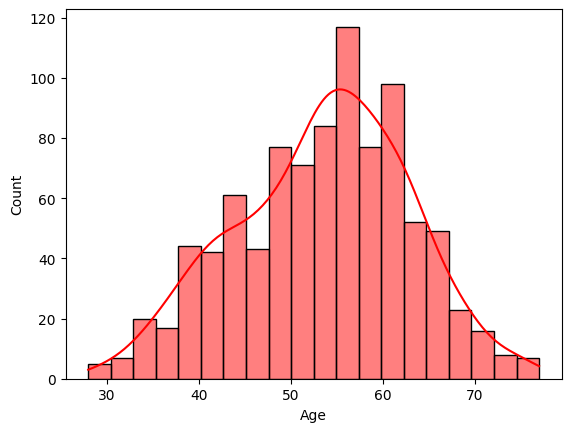

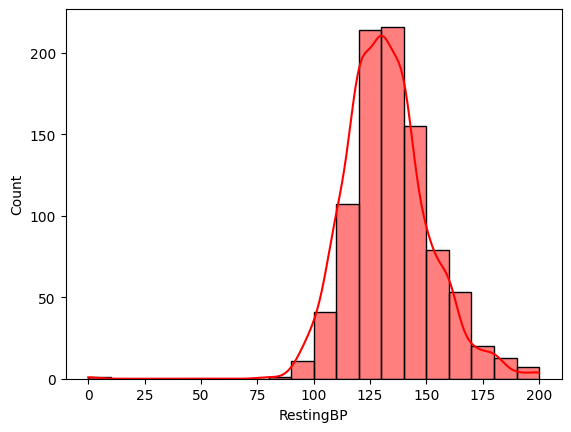

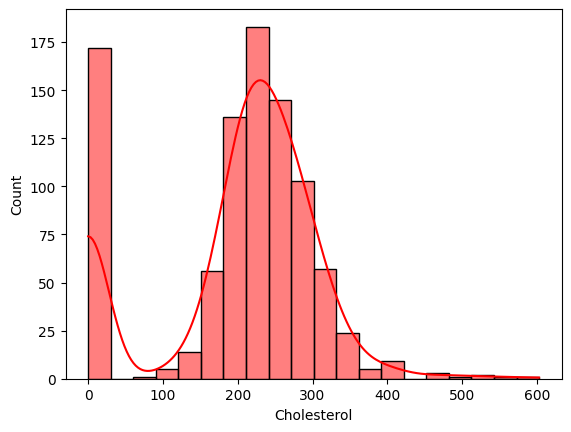

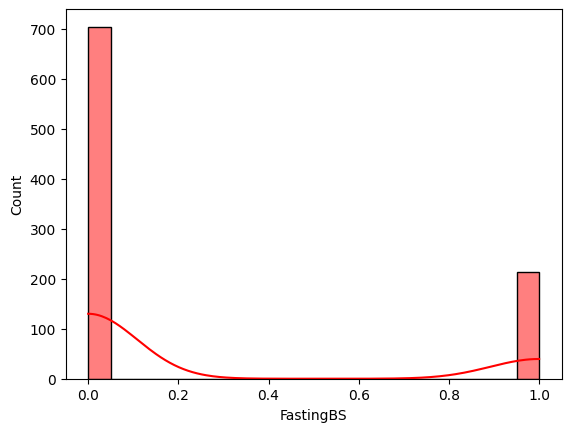

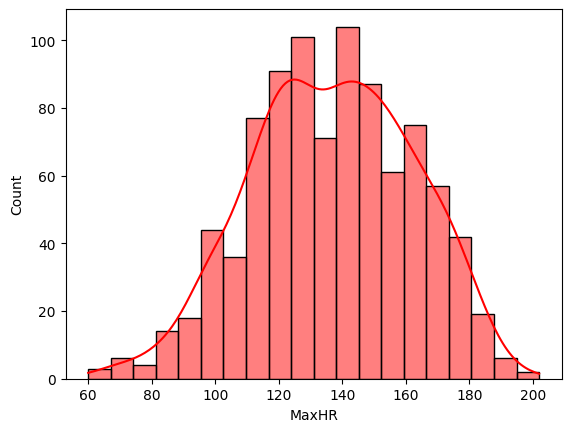

In [ ]:
numeric_columns = ['Age','RestingBP', 'Cholesterol','FastingBS','MaxHR']
for col in numeric_columns:
  sns.histplot(df[col],kde = True, bins = 20 , color ='red')
  plt.show()

In [ ]:
ch_mean = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [ ]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [ ]:
rest_mean = df.loc[df['RestingBP']!=0 ,'RestingBP'].mean()
rest_mean

np.float64(132.54089422028352)

In [ ]:
final_rest_mean = rest_mean.round(0)
final_rest_mean

np.float64(133.0)

In [ ]:
df['RestingBP'] = df['RestingBP'].replace(0,final_rest_mean)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


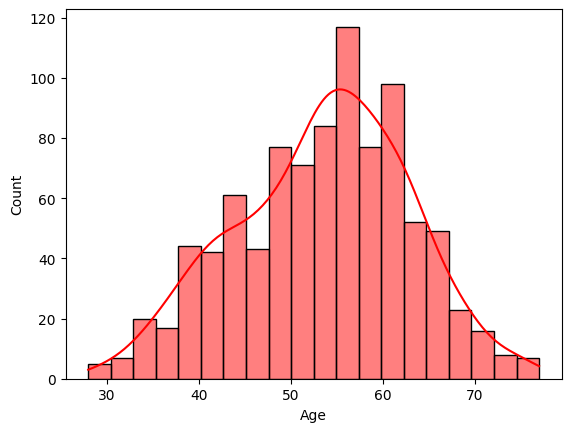

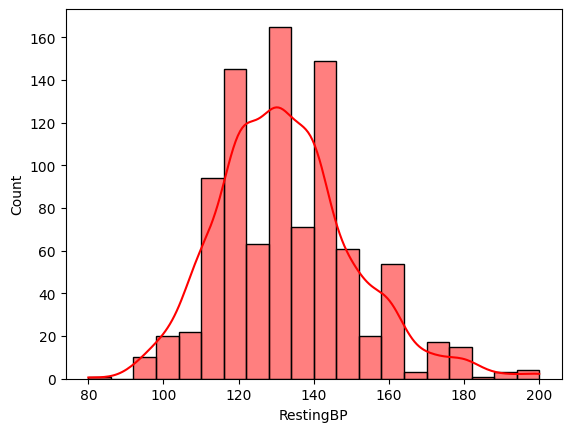

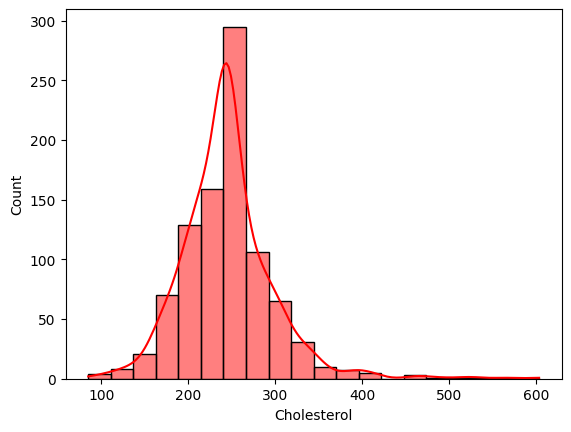

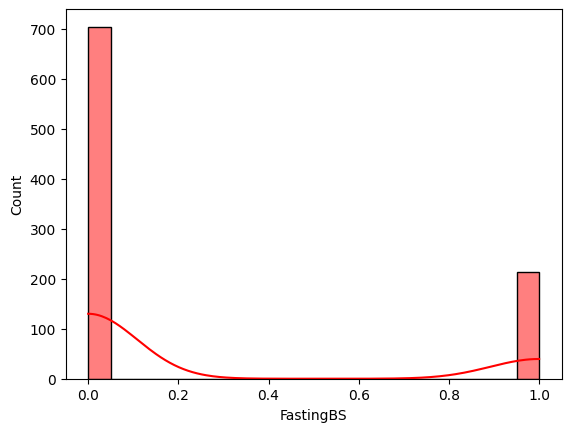

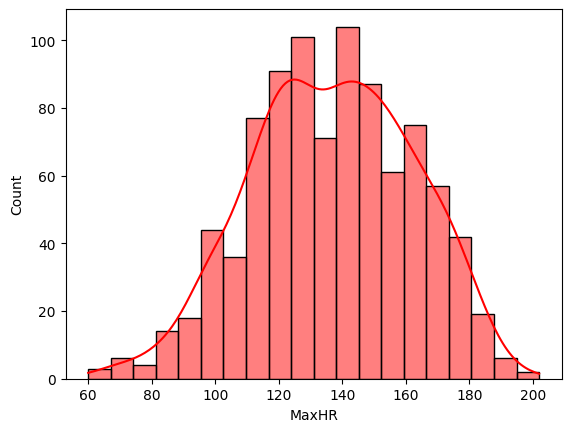

In [ ]:
numeric_columns = ['Age','RestingBP', 'Cholesterol','FastingBS','MaxHR']
for col in numeric_columns:
  sns.histplot(df[col],kde = True, bins = 20 , color ='red')
  plt.show()

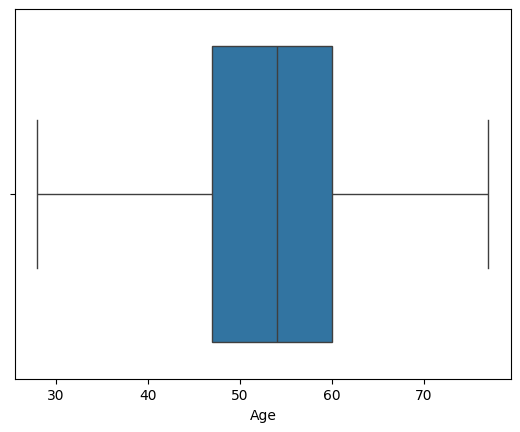

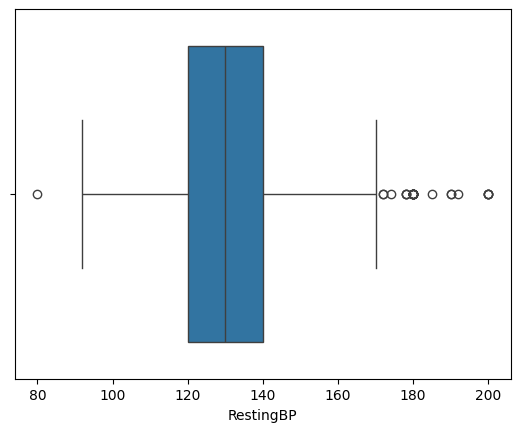

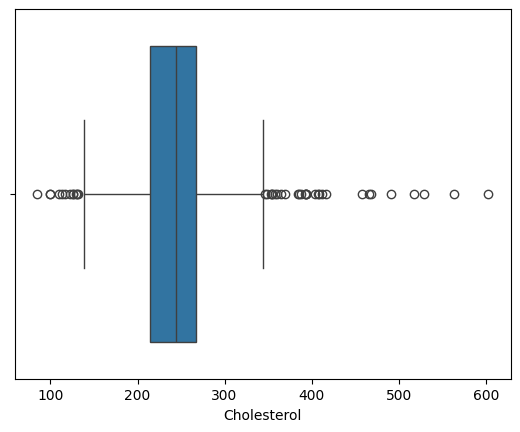

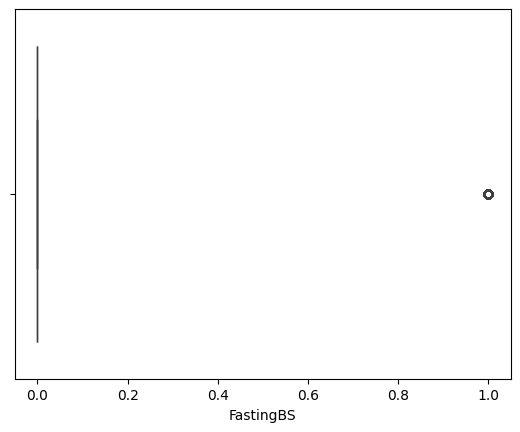

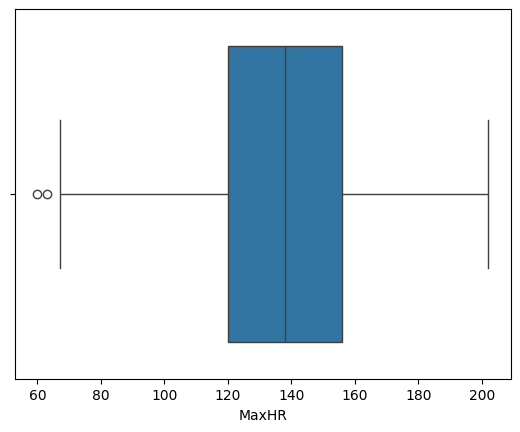

In [ ]:
for col in numeric_columns:
  sns.boxplot(x=df[col])
  plt.show()

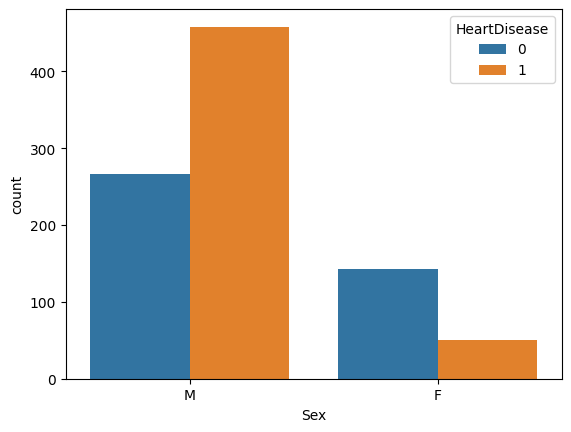

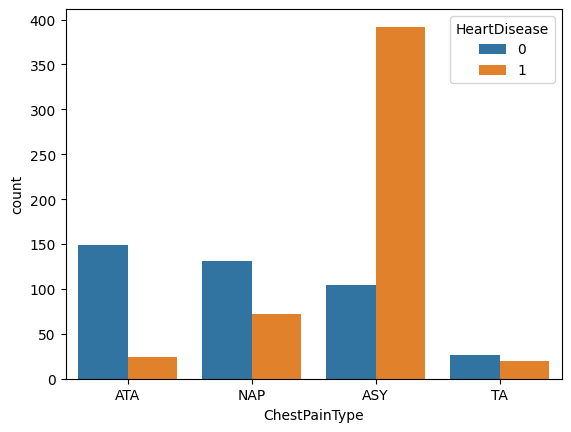

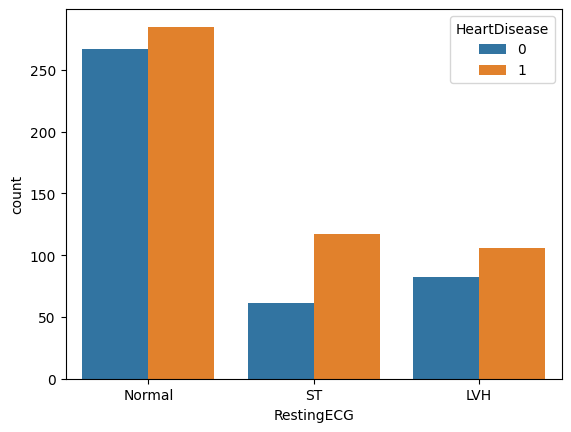

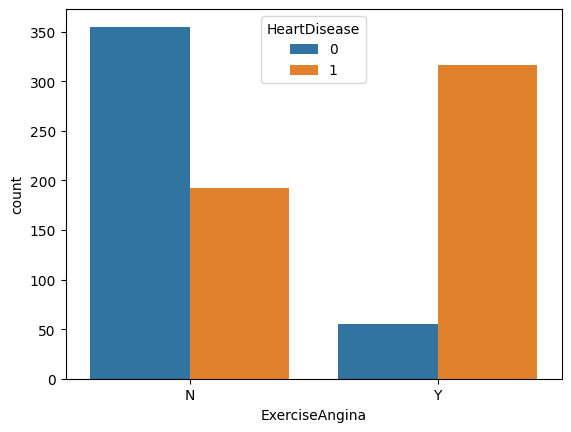

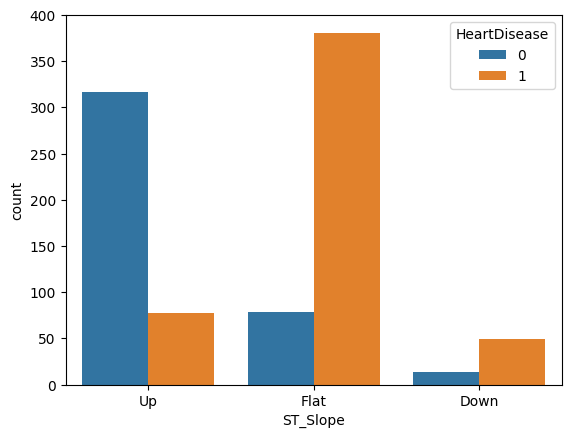

In [ ]:
categorical_columns = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
for col in categorical_columns:
  sns.countplot( x=df[col],hue = df['HeartDisease'])
  plt.show()

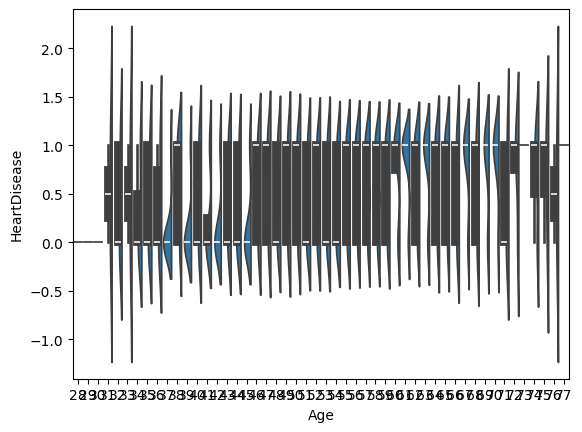

In [ ]:
sns.violinplot(x=df['Age'],y=df['HeartDisease'],split = True)
plt.show()

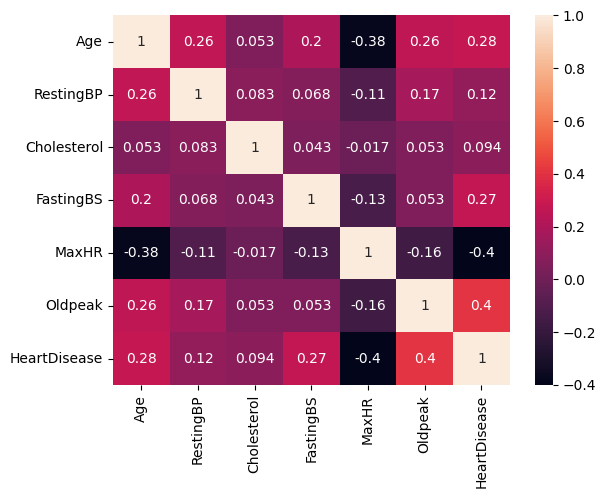

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
df_new = df.copy()

In [ ]:
df_new = pd.get_dummies(df,drop_first=True)
df_new.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [ ]:
from sklearn.preprocessing import StandardScaler
cols = ['Age','RestingBP','Cholesterol','MaxHR']
scaler = StandardScaler()
df_new[cols] = scaler.fit_transform(df_new[cols])
df_new.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.832529,0,1.382928,0.0,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.527163,-1.212922,0,0.754157,1.0,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141345,0.719935,0,-1.525138,0.0,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.303591,-0.574892,0,-1.132156,1.5,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.970994,-0.931438,0,-0.581981,0.0,0,True,False,True,False,True,False,False,False,True


In [ ]:
for col in df_new.columns:
    if df_new[col].dtype == 'bool':
        df_new[col] = df_new[col].astype(int)

df_new.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.832529,0,1.382928,0.0,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527163,-1.212922,0,0.754157,1.0,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141345,0.719935,0,-1.525138,0.0,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303591,-0.574892,0,-1.132156,1.5,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.970994,-0.931438,0,-0.581981,0.0,0,1,0,1,0,1,0,0,0,1


In [ ]:
df_new.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.832529,0,1.382928,0.0,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527163,-1.212922,0,0.754157,1.0,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141345,0.719935,0,-1.525138,0.0,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303591,-0.574892,0,-1.132156,1.5,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.970994,-0.931438,0,-0.581981,0.0,0,1,0,1,0,1,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score

In [ ]:
X = df_new.drop('HeartDisease',axis=1)
y = df_new['HeartDisease']


In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    "SVM": SVC()
}

In [ ]:
result =[]

In [ ]:
for name , model in models.items():
  model.fit(X_train , Y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(Y_test,y_pred)
  f1 = f1_score(Y_test,y_pred)
  result.append({
      "model":name,
      "Accuracy":round(accuracy,4),
      "f1_score":round(f1,4)
      }
  )


In [ ]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.8641, 'f1_score': 0.8792},
 {'model': 'Naive Bayes', 'Accuracy': 0.8478, 'f1_score': 0.8614},
 {'model': 'K-Nearest Neighbors', 'Accuracy': 0.8533, 'f1_score': 0.8732},
 {'model': 'Decision Tree', 'Accuracy': 0.8152, 'f1_score': 0.835},
 {'model': 'SVM', 'Accuracy': 0.837, 'f1_score': 0.8585}]

In [ ]:
import joblib
joblib.dump(models['Logistic Regression'],'Logistic_regression.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.to_list,'columns.pkl')



['columns.pkl']